In [1]:
from qldpc_sim import *
from qldpc_sim.qldpc_experiment import *
from qldpc_sim.qec_code import *
from qldpc_sim.data_structure import *
import stim
import numpy as np

In [2]:
from qldpc_sim.qec_code.rotated_surface_code import RotatedSurfaceCode


def setup_cnot_exp():
    patch1 = RotatedSurfaceCode.from_distance(3, code_name="p1", system_coordinate=(0,0))
    patch2 = RotatedSurfaceCode.from_distance(3, code_name="p2", system_coordinate=(0,1))
    qm = qldpc_experiment.QuantumMemory(size=600)
    patches = [patch1, patch2]
    mapqb = {}
    for c in patches:
        for lq in c.logical_qubits:
            mapqb[lq.logical_x] = c
            mapqb[lq.logical_z] = c

    ctx = Context(
        codes=[patch1, patch2],
        logical_qubits=patch1.logical_qubits + patch2.logical_qubits,
        initial_assignement=mapqb,
        memory=qm,
    )

    return ctx

In [3]:
from qldpc_sim.ckbb_surgery.measurement import CKBBMeasurement
from qldpc_sim.rsc_surgery.rsc_surgery import SurgeMeasurement
from qldpc_sim.qldpc_experiment.qec_gadget import Readout
from qldpc_sim.data_structure.tanner_graph_algebra import TannerGraphAlgebra as tga

def get_joinm_program(initial_state1, initial_state2, joint_pauli, readout_basis):
    context = setup_cnot_exp()

    p1 = context.codes[0]
    p2 = context.codes[1]

    tga.visualize(p1.tanner_graph | p2.tanner_graph)
    for n in p1.tanner_graph.variable_nodes:
        print(n.coordinates)
    if joint_pauli == "XX":
        ckbbm = [
            CKBBMeasurement(
                distance=3,
                context=context,
                tag="CKBBM",
                logical_targets=[
                    p2.logical_qubits[0].logical_x,
                    p1.logical_qubits[0].logical_x,
                ],
            ),
        ]
    else:
        ckbbm = [
            CKBBMeasurement(
                distance=3,
                context=context,
                tag="CKBBM",
                logical_targets=[
                    p2.logical_qubits[0].logical_z,
                    p1.logical_qubits[0].logical_z,
                ],
            ),
        ]
    return (
        [
            InitializeCode(
                code=p1,
                context=context,
                tag=f"init_{p1.id}",
                initial_state=initial_state1,
            )
        ]
        + [
            InitializeCode(
                code=p2,
                context=context,
                tag=f"init_{p2.id}",
                initial_state=initial_state2,
            )
        ]
        + [
            StabMeasurement(code=p, context=context, tag=f"isb_2_{p.id}", round=3)
            for p in [p1, p2]
        ]
        + ckbbm
        + [
            StabMeasurement(code=p, context=context, tag=f"isb_3_{p.id}", round=3)
            for p in [p1, p2]
        ]
        + [
            LM(
                logical_targets=[p1.logical_qubits[0].logical_x if readout_basis == "X" else p1.logical_qubits[0].logical_z],
                context=context,
                tag=f"p1",
                basis=PauliChar.X if readout_basis == "X" else PauliChar.Z,
                reset_qubits=False,
            ),
            LM(
                logical_targets=[p2.logical_qubits[0].logical_x if readout_basis == "X" else p2.logical_qubits[0].logical_z],
                context=context,
                tag=f"p2",
                basis=PauliChar.X if readout_basis == "X" else PauliChar.Z,
                reset_qubits=False,
            ),
            Readout(
                code=p1,
                context=context,
                tag=f"readout_{p1.id}",
                basis=PauliChar.X if readout_basis == "X" else PauliChar.Z,
            ),
            Readout(
                code=p2,
                context=context,
                tag=f"readout_{p2.id}",
                basis=PauliChar.X if readout_basis == "X" else PauliChar.Z,
            ),
        ]
    ), context

In [4]:
from typing import Dict, List, Set, Tuple

from qldpc_sim.qldpc_experiment.qec_gadget import LogicGadget


def evaluate(ctx, program: List[QECGadget]) -> Tuple[List[str], Dict[str, Set[int]]]:
    """Evaluate a qLDPC program in the context.

    Args:
        program (List[QECGadget]): The list of gadgets to evaluate in the context.
    """
    logical_outcomes: Dict[str, Set[int]] = {}
    instructions = []
    for gadget in program:
        compilers, outcomes = gadget.build_compiler_instructions()
        for compiler in compilers:
            n_instructions, measurements = compiler.compile(ctx.memory)
            instructions.extend(n_instructions)
            if measurements is not None:
                ctx.record.add_measurements(measurements)
        for outcome in outcomes:
            ctx.record.add_event(outcome)
            if outcome.type == EventType.FRAME_CORRECTION:
                logical_qubit = ctx.map_operator_to_qubits[outcome.target]
                ctx.frame_tracker.add_correction(
                    logical_qubit, outcome.target.logical_type, outcome.measured_nodes
                )
            if outcome.type == EventType.OBSERVABLE:
                if isinstance(outcome.target, LogicalOperator):
                    if outcome.tag not in logical_outcomes:
                        logical_outcomes[outcome.tag] = set()
                    logical_outcomes[outcome.tag] |= set(outcome.measured_nodes)
                    logical_outcomes[outcome.tag] |= set(
                        ctx.frame_tracker.get_correction(
                            ctx.map_operator_to_qubits[outcome.target],
                            outcome.target.logical_type,
                        )
                    )

    return instructions, logical_outcomes, ctx.record

(4, 0, 0, 0)
(4, 4, 0, 0)
(4, 2, 0, 0)
(2, 4, 0, 0)
(0, 0, 0, 0)
(2, 2, 0, 0)
(0, 4, 0, 0)
(2, 0, 0, 0)
(0, 2, 0, 0)
Correction paths: {LogicalOperator(id=UUID('baf2c5c6-fd85-47e8-82d0-488a83bd21c2'), logical_type=<PauliChar.X: 'X'>, operator=PauliString(string=(<PauliChar.X: 'X'>, <PauliChar.X: 'X'>, <PauliChar.X: 'X'>)), target_nodes=(VariableNode(id=UUID('8d82eafc-8e57-43a3-ac56-60336abff7d3'), tag='v_0_p2', coordinates=(0, 0, 0, 1)), VariableNode(id=UUID('27576a10-8db5-459f-b2d8-d5f76d480ee8'), tag='v_3_p2', coordinates=(0, 2, 0, 1)), VariableNode(id=UUID('0669ec71-4b79-4a92-837b-0f903d04dadc'), tag='v_6_p2', coordinates=(0, 4, 0, 1)))): {VariableNode(id=UUID('ce7f4538-be6b-47a4-9083-3b7922a818d3'), tag='_c_x_0_p2_T', coordinates=(1, 0, 1, 0)), VariableNode(id=UUID('e4122960-a6fd-44fe-a63b-bfde6c1d1feb'), tag='_c_x_3_p2_T', coordinates=(3, 0, 1, 0)), VariableNode(id=UUID('6d3fc342-61e9-490e-82ad-80cbba673f05'), tag='bv_l0', coordinates=(0, 0, 2, 0))}, LogicalOperator(id=UUID('d13bf

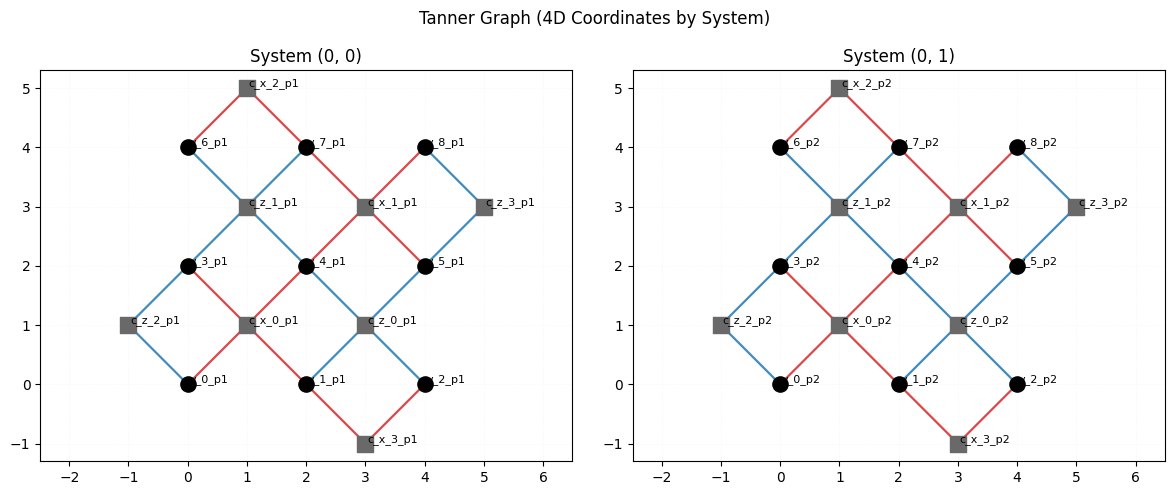

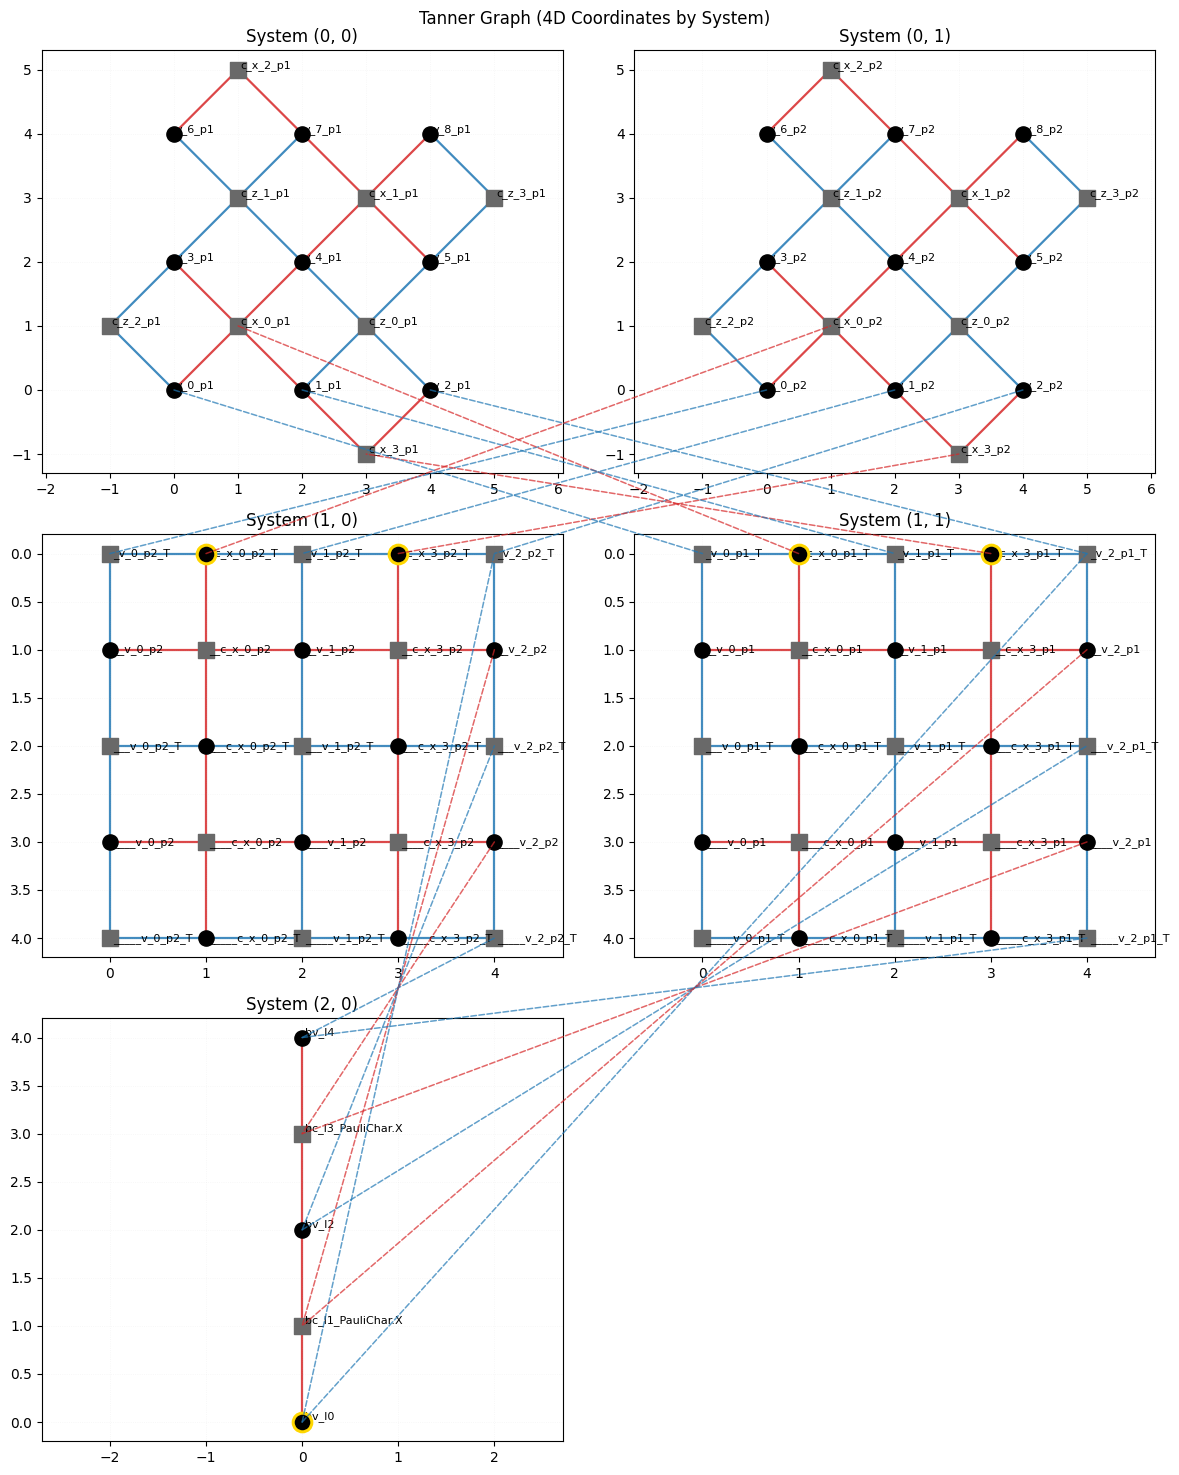

In [5]:
from collections import Counter
from itertools import combinations
import json
from pathlib import Path

from qldpc_sim.qldpc_experiment import context
from qldpc_sim.qldpc_experiment.interpreter import concat_events_per_sample, run, xor_event_nodes

prog, ctx = get_joinm_program(
    initial_state1=PauliEigenState.Z_plus,
    initial_state2=PauliEigenState.X_plus,
    joint_pauli="ZZ",
    readout_basis="X",
)

p, lo, rec = evaluate(ctx, prog)




In [6]:
from pprint import pprint


def _node_name(node):
    return getattr(node, "tag", str(node))


def _format_target(target):
    if target is None:
        return None
    if isinstance(target, (set, list, tuple)):
        return [_format_target(t) for t in target]
    logical_type = getattr(target, "logical_type", None)
    target_id = getattr(target, "id", None)
    if logical_type is not None and target_id is not None:
        return f"{logical_type}:{target_id}"
    return str(target)



print("\n=== lo (logical observable supports) ===")
lo_pretty = {
    tag: sorted(_node_name(node) for node in nodes)
    for tag, nodes in sorted(lo.items(), key=lambda item: item[0])
}
pprint(lo_pretty, sort_dicts=False)


print("\n=== rec (measurement record) ===")
print(f"num_measurement_recorded: {rec.num_measurement_recorded}")


print("\nEvents:")
events_pretty = []
for event, end_idx in rec.events.items():
    events_pretty.append(
        {
            "tag": event.tag,
            "type": event.type.value,
            "size": event.size,
            "end_idx": end_idx,
            "target": _format_target(event.target),
            "nodes": sorted(_node_name(node) for node in event.measured_nodes),
        }
    )
pprint(events_pretty, sort_dicts=False)




=== lo (logical observable supports) ===
{'LogicalMeasurement_p1': ['_c_x_0_p1_T',
                           '_c_x_3_p1_T',
                           'v_0_p1',
                           'v_3_p1',
                           'v_6_p1'],
 'LogicalMeasurement_p2': ['_c_x_0_p2_T',
                           '_c_x_3_p2_T',
                           'bv_l0',
                           'v_0_p2',
                           'v_3_p2',
                           'v_6_p2']}

=== rec (measurement record) ===
num_measurement_recorded: 311

Events:
[{'tag': 'StabMeasurement_isb_2_9a55fc67-5fa2-4f2d-b116-46d2fed908c3',
  'type': 'stab_measurement',
  'size': 8,
  'end_idx': 40,
  'target': None,
  'nodes': ['c_x_0_p1',
            'c_x_1_p1',
            'c_x_2_p1',
            'c_x_3_p1',
            'c_z_0_p1',
            'c_z_1_p1',
            'c_z_2_p1',
            'c_z_3_p1']},
 {'tag': 'StabMeasurement_isb_2_f125505e-8ccb-4aa7-9da2-c236397de98f',
  'type': 'stab_measurement',
  'size': 8,


In [7]:
# Run stim and compute logical outcomes directly from lo and rec.
num_shots = 100
shots = stim.Circuit("\n".join(p)).compile_sampler().sample(shots=num_shots).astype(np.uint8)

# rec_idx(node): latest record index for each measured node.
rec_idx = {node: idxs[-1] for node, idxs in rec.measurements.items() if idxs}

# For each logical support l in lo: outcome = XOR over shots[:, rec_idx(i)] for i in l.
logical_record_idx = {}
logical_outcomes = {}
for tag, l in lo.items():
    idx = sorted({rec_idx[i] for i in l if i in rec_idx})
    logical_record_idx[tag] = idx
    if idx:
        logical_outcomes[tag] = np.bitwise_xor.reduce(shots[:, idx], axis=1).astype(np.uint8)
    else:
        logical_outcomes[tag] = np.zeros(num_shots, dtype=np.uint8)

print(f"Stim shots: {num_shots}")
print("logical_record_idx:")
for tag in sorted(logical_record_idx):
    print(f"  {tag}: {logical_record_idx[tag]}")

print("\nlogical_outcomes (first 10 shots):")
for tag in sorted(logical_outcomes):
    print(f"  {tag}: {logical_outcomes[tag][:10].tolist()}")

Stim shots: 100
logical_record_idx:
  LogicalMeasurement_p1: [197, 219, 282, 285, 290]
  LogicalMeasurement_p2: [196, 213, 221, 303, 308, 310]

logical_outcomes (first 10 shots):
  LogicalMeasurement_p1: [1, 1, 0, 1, 1, 1, 0, 0, 1, 0]
  LogicalMeasurement_p2: [0, 0, 0, 0, 0, 1, 0, 1, 1, 1]


In [8]:
from collections import Counter

tags = sorted(logical_outcomes)
joint = Counter(zip(*(logical_outcomes[t].tolist() for t in tags)))
print("(" + ", ".join(tags) + "): count")
for outcome, count in sorted(joint.items()):
    print(f"  {outcome}: {count}")


(LogicalMeasurement_p1, LogicalMeasurement_p2): count
  (0, 0): 26
  (0, 1): 24
  (1, 0): 24
  (1, 1): 26
